# Анализ текстов отзывов на одежду

**ГП5 - этап 1 (неструктурированные данные)**

Датасет: [Women's Clothing E-Commerce Reviews](https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews)

Это первая часть проекта, в этом ноутбуке наша команда работала с текстами отзывов и с построением рекуррентной нейронной сети, которая превращает текст отзыва в набор табличных признаков. Вторая часть проекта будет использовать эти признаки вместе с исходными табличными полями, чтобы предсказывать полезность отзыва `Positive Feedback Count`

## 1. Введение и ML-постановка

На вход модели подается текст отзыва `Review Text`,
при наличии, вместе с заголовком `Title`, затем модель должна одновременно решить несколько задач:
1. определить релевантен ли отзыв товару
2. оценить эмоциональную окраску отзыва по шкале 0–100
3. определить, есть ли в отзыве информация о ключевых признаках одежды: посадка, размер, комфорт, материал, качество и цвет

В результате на следующий этап передается обогащенный файл, в котором к исходным колонкам датасета добавлены предсказанные моделью признаки

## 2. Библиотеки и настройка

In [2]:
import os
import re
import json
import pickle
import random
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error, mean_squared_error)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

## 3. Загрузка датасета

Загружаем датасет отзывов на женскую одежду. Кратко по основным полям, которые будем использовать:
- `Review Text` - текст отзыва
- `Title` - заголовок отзыва
- `Rating` - оценка товара от 1 до 5
- `Recommended IND` - рекомендует ли покупательница товар (0/1)

In [4]:
df = pd.read_csv("data/Womens Clothing E-Commerce Reviews.csv", index_col=0)
df

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
...,...,...,...,...,...,...,...,...,...,...
23481,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23482,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23483,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23484,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              23486 non-null  int64 
 1   Age                      23486 non-null  int64 
 2   Title                    19676 non-null  object
 3   Review Text              22641 non-null  object
 4   Rating                   23486 non-null  int64 
 5   Recommended IND          23486 non-null  int64 
 6   Positive Feedback Count  23486 non-null  int64 
 7   Division Name            23472 non-null  object
 8   Department Name          23472 non-null  object
 9   Class Name               23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 2.0+ MB


## 4. Первичный EDA


In [6]:
df.isna().sum()

,0
Clothing ID,0
Age,0
Title,3810
Review Text,845
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,14
Department Name,14
Class Name,14


In [7]:
print(f"Отзывов без названия: {df["Title"].isna().sum() / len(df) * 100:.1f}%")
print(f"Отзывов без текста: {df["Review Text"].isna().sum() / len(df) * 100:.1f}%")

Отзывов без названия: 16.2%
Отзывов без текста: 3.6%


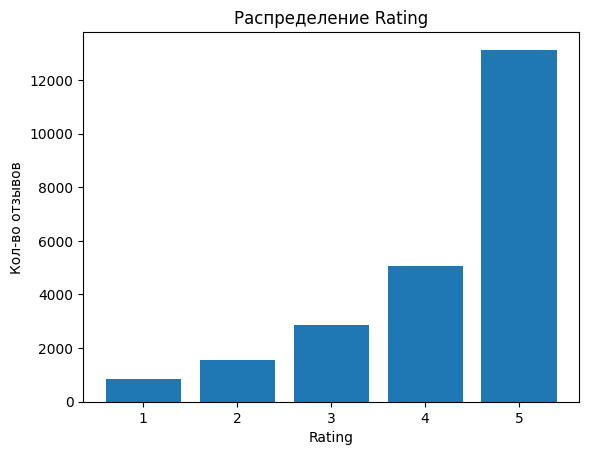

In [8]:
rating_counts = df["Rating"].value_counts().sort_index()
plt.bar(rating_counts.index, rating_counts.values)
plt.title("Распределение Rating")
plt.xlabel("Rating")
plt.ylabel("Кол-во отзывов")

plt.show()

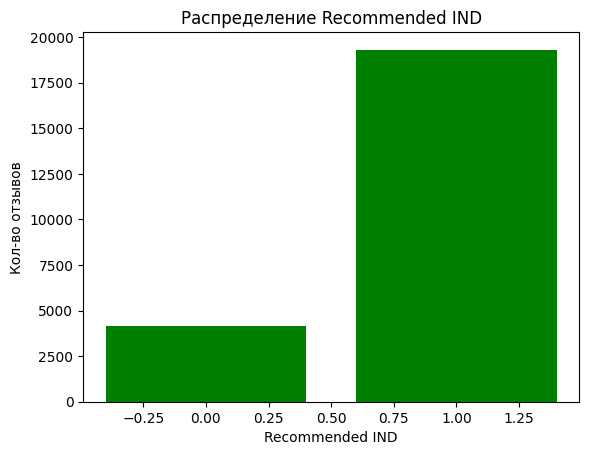

In [9]:
rating_counts = df["Recommended IND"].value_counts().sort_index()
plt.bar(rating_counts.index, rating_counts.values, color="green")
plt.title("Распределение Recommended IND")
plt.xlabel("Recommended IND")
plt.ylabel("Кол-во отзывов")

plt.show()


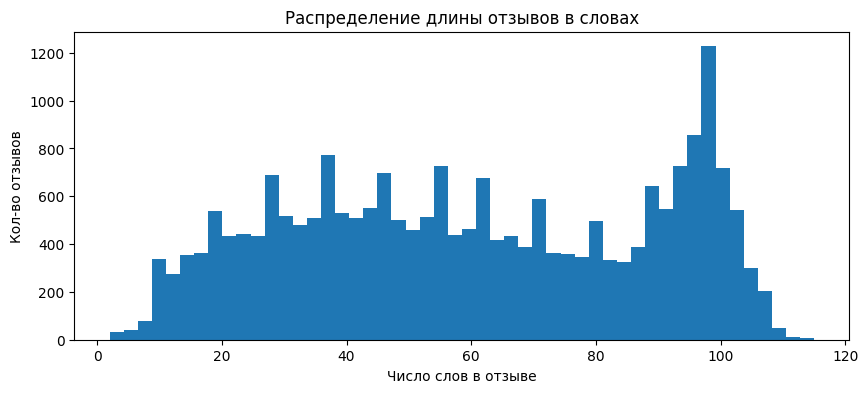

In [10]:
review_len = df["Review Text"].dropna().str.split().str.len()

plt.figure(figsize=(10, 4))
plt.hist(review_len, bins=50)
plt.title("Распределение длины отзывов в словах")
plt.xlabel("Число слов в отзыве")
plt.ylabel("Кол-во отзывов")
plt.show()

In [11]:
review_len.describe()

,Review Text
count,22641.000000
mean,60.196679
std,28.534612
min,2.000000
25%,36.000000
50%,59.000000
75%,88.000000
max,115.000000


- 3.6% отзывов вообще без текста для нас они бесполезны, такие строки дропаем
- рейтинг сильно смещен в сторону оценки 5 и большая часть покупателей рекомендуют товар, т.е. классы тональности несбалансированы, в основном отзывы должны быть позитивными

## 5. Предобработка текста

Готовим текст к подаче в нейросеть:

1. Пропущенные заголовки заменяем на пустую строку и склеиваем заголовок с текстом отзыва
2. Строки, у которых после склейки текст пустой, удаляем, ибо модели нечего анализировать
3. Делаем мягкую очистку: нижний регистр, убираем лишние пробелы и спецсимволы

In [12]:
def clean_text(text):
  # нижний регистр
  text = str(text).lower()

  # html-теги
  text = re.sub(r"<[^>]+>", " ", text)

  # оставляем буквы, цифры и апострофы
  text = re.sub(r"[^a-z0-9'\s]", " ", text)

  # схлопываем пробелы
  text = re.sub(r"\s+", " ", text).strip()
  return text

In [13]:
df["Title"] = df["Title"].fillna("")
df["Review Text"] = df["Review Text"].fillna("")

df["full_text"] = (df["Title"] + " " + df["Review Text"]).str.strip()
df["clean_text"] = df["full_text"].apply(clean_text)

df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)
df[["Title", "Review Text", "clean_text"]]

,Title,Review Text,clean_text
0,,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky and sexy and comfor...
1,,Love this dress! it's sooo pretty. i happene...,love this dress it's sooo pretty i happened to...
2,Some major design flaws,I had such high hopes for this dress and reall...,some major design flaws i had such high hopes ...
3,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",my favorite buy i love love love this jumpsuit...
4,Flattering shirt,This shirt is very flattering to all due to th...,flattering shirt this shirt is very flattering...
...,...,...,...
22637,Great dress for many occasions,I was very happy to snag this dress at such a ...,great dress for many occasions i was very happ...
22638,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",wish it was made of cotton it reminds me of ma...
22639,"Cute, but see through","This fit well, but the top was very see throug...",cute but see through this fit well but the top...
22640,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,very cute dress perfect for summer parties and...


Возмем 15000 самых частых слов (потом в токенезаторе обнаружим что всего уникальных 13к слов), в качестве словаря для токенизации и 150 слов макс батч, это покроет все отзывы в дс

In [14]:
max_words = 15000
max_len = 150

## 6. Создание целевых переменных

Создаем целевые переменные эвристически, по ключевым словам и существующим полям

P.S. Поскольку мы бедные студенты с ограниченным количеством времени и очень ленивые, то вручную разметить данные мы очевидно не будем, поэтому порой будут FP и FN, о которых мы никогда не узнаем, ибо ключевые слова, например "colorful
personality" пометятся как информация о цвете, а перефразировки типа "hugs my
figure" пропустятся

Цели:
1. `relevance` - отзыв релевантен товару
2. `sentiment_score` - оценка тональности от 0 до 100.
Строим из 3 сигналов:
- `Rating`
- `Recommended IND`
- Счетчик позитивных и негативных слов в тексте
3. Есть ли в тексте слова из тематических словарей:
- `has_fit_info`
- `has_size_info`
- `has_comfort_info`
- `has_material_info`
- `has_quality_info`
- `has_color_info`
- `has_type_info`

 тематические словари ключевых слов (нормальный, но не исчерпывающий кнч)

In [15]:
keywords = {
  "fit": ["fit", "fits", "fitted", "fitting", "loose", "baggie", "tight", "flattering", "shape", "cut", "waist", "hips", "chest", "sleeves", "length", "snug"],
  "size": ["size", "sized", "sizing", "small", "large", "medium", "petite", "xs", "oversize", "xl", "xxl", "runs small", "runs large", "true to size", "tts"],
  "comfort": ["comfortable", "comfy", "comfort", "soft", "itchy", "scratchy", "wearable", "easy to wear", "feels", "feel", "cozy", "breathable"],
  "material": ["material", "fabric", "cotton", "polyester", "wool", "silk", "linen", "denim", "knit", "stretch", "stretchy", "texture", "lace", "rayon"],
  "quality": ["quality", "well made", "cheap", "expensive", "durable", "poorly made", "seams", "stitching", "thin", "thick", "sturdy", "flimsy"],
  "color": ["color", "colour", "black", "white", "red", "blue", "green", "yellow", "pink", "navy", "bright", "dark", "shade", "print", "pattern"],
  "type": ["dress", "top", "shirt", "blouse", "skirt", "pants", "socks",  "hoodie", "jeans", "sweater", "jacket", "coat"]
}

собираем regex

In [16]:
def make_pattern(words):
  parts = []
  for w in words:
    escaped = re.escape(w)
    parts.append(r"\b" + escaped + r"\b")
  return re.compile("|".join(parts))

In [17]:
flag_patterns = {k: make_pattern(v) for k, v in keywords.items()}
product_pattern = make_pattern([word for sublist in keywords.values() for word in sublist])

for name, pattern in flag_patterns.items():
  df[f"has_{name}_info"] = df["clean_text"].str.contains(pattern).astype(int)

df["relevance"] = df["clean_text"].str.contains(product_pattern).astype(int)

sentiment_score базово берем просто из Rating, потом правка на текст и рекомендацию

In [18]:
positive_words = ["love", "lovely", "perfect", "beautiful", "great", "amazing", "gorgeous", "wonderful", "excellent", "favorite", "compliment", "cosy", "nice", "elegant", "handsome", "stunning", "chic", "enchanting"]
negative_words = ["disappointed", "disappointing", "returned", "returning", "awful", "terrible", "bad", "ugly", "unflattering", "horrible", "waste", "nasty", "tacky", "tasteless"]

pos_pattern = make_pattern(positive_words)
neg_pattern = make_pattern(negative_words)

1. Рейтинг: 1 -> 0, 5 -> 100
2. Рекомендация: +-15
3. Тон текста: до +-15

In [19]:
base = (df["Rating"] - 1) / 4 * 100
rec_adj = (df["Recommended IND"] * 2 - 1) * 15

pos_cnt = df["clean_text"].str.count(pos_pattern)
neg_cnt = df["clean_text"].str.count(neg_pattern)

text_adj = (pos_cnt - neg_cnt).clip(-5, 5) * 3

df["sentiment_score"] = (base + rec_adj + text_adj).clip(0, 100)

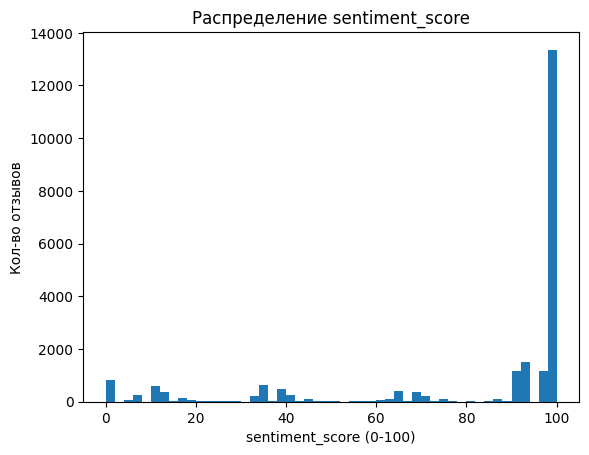

In [20]:
plt.hist(df["sentiment_score"], bins=50)
plt.title("Распределение sentiment_score")
plt.xlabel("sentiment_score (0-100)")
plt.ylabel("Кол-во отзывов")
plt.show()

распределение всех целевых флагов, проверяем нет ли пустых или слишком редких классов


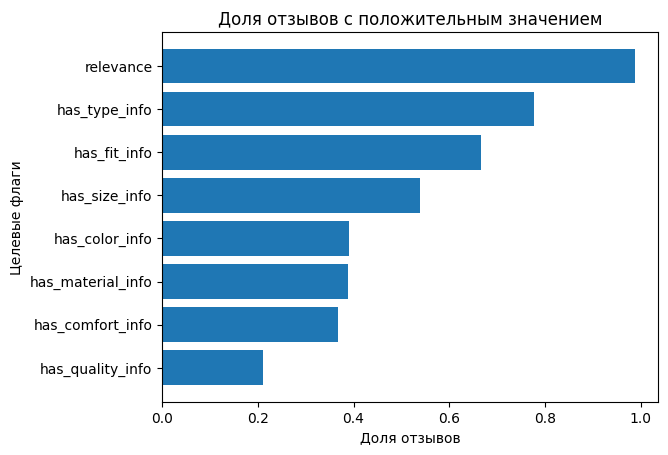

In [21]:
target_bins = [f"has_{k}_info" for k in keywords] + ["relevance"]

flag_shares = df[target_bins].mean().sort_values()
plt.barh(flag_shares.index, flag_shares.values)
plt.title("Доля отзывов с положительным значением")
plt.xlabel("Доля отзывов")
plt.ylabel("Целевые флаги")
plt.show()

Пустых классов нет, у каждого флага есть и нули, и
единицы, значит на каждой задаче модели есть чему учиться.

Поскольку у нас `relevance` почти всегда равен 1 сделаем далее признак как доп, а не как основной, ибо про товар и так почти все пишут

## 7. Разделение данных

Делим данные на train 70%, valid 15% и test 15%:

In [22]:
df_train_val, df_test = train_test_split(df, test_size=0.15, random_state=42)
df_train, df_val = train_test_split(df_train_val, test_size=0.15 / 0.85, random_state=42)

Если строить словарь по всем данным, слова, которых нет в словаре, токенизатор заменяет на out of vocabulary

In [23]:
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df_train["clean_text"])
len(tokenizer.word_index)

13095

Текст -> последовательность индексов -> padding

In [24]:
def texts_to_padded(texts):
  seq = tokenizer.texts_to_sequences(texts)
  return pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

In [25]:
X_train = texts_to_padded(df_train["clean_text"])
X_val = texts_to_padded(df_val["clean_text"])
X_test = texts_to_padded(df_test["clean_text"])
X_train.shape, X_val.shape, X_test.shape

((15848, 150), (3397, 150), (3397, 150))

In [26]:
with open("artifacts/models/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

1. целевые переменные собираем в словари

2. sentiment масштабируем в [0, 1] так сигмовидный выход и mseloss работают стабильнее, а в шкалу 0-100 вернемся при предсказании

In [27]:
def make_targets(d):
  targets = {"relevance": d["relevance"].values.astype("float64"),
              "sentiment": (d["sentiment_score"].values / 100.0).astype("float64")}

  for k in keywords:
    targets[k] = d[f"has_{k}_info"].values.astype("float64")

  return targets

In [28]:
output_names = ["relevance", "sentiment"] + [k for k in keywords]
y_train = make_targets(df_train)
y_val = make_targets(df_val)
y_test = make_targets(df_test)
output_names

['relevance',
 'sentiment',
 'fit',
 'size',
 'comfort',
 'material',
 'quality',
 'color',
 'type']

## 8. Multi-output рекуррентная модель

Архитектура у всех моделей одинаковая:

1. Input - последовательность из max_len индексов
2. Embedding - каждое слово -> плотный вектор размерности 64
3. SimpleRNN / GRU / LSTM - читает последовательность и сжимает ее в один вектор
4. Dropout - борьба с переобучением
5. Dense 64, relu - общее скрытое представление
6. 9 выходов

In [29]:
hparams = {
  "max_words": max_words,
  "max_len": max_len,
  "embedding_dim": 64,
  "rnn_units": 64,
  "dropout": 0.3,
  "dense_units": 64,
  "batch_size": 128,
  "epochs": 15,
  "optimizer": "adam",
  "learning_rate": 1e-3,
  "sentiment_loss_weight": 5,
  "early_stopping_patience": 3,
}

In [30]:
rnn_layers = {
    "SimpleRNN": layers.SimpleRNN,
    "GRU": layers.GRU,
    "LSTM": layers.LSTM,
}

Функция строит multi-output модель с заданным типом рекуррентного слоя

In [40]:
def build_model(rnn_type):
  rnn_layer = rnn_layers[rnn_type]

  inp = layers.Input(shape=(hparams["max_len"],), name="tokens")

  x = layers.Embedding(input_dim=hparams["max_words"], output_dim=hparams["embedding_dim"], mask_zero=True, name="embedding")(inp)
  x = rnn_layer(hparams["rnn_units"], name=rnn_type.lower())(x)
  x = layers.Dropout(hparams["dropout"])(x)
  x = layers.Dense(hparams["dense_units"], activation="relu", name="shared_dense")(x)

  outputs = []
  for name in output_names:
    outputs.append(layers.Dense(1, activation="sigmoid", name=name)(x))

  model = keras.Model(inputs=inp, outputs=outputs, name=f"{rnn_type}_multi_output")

  losses = {name: "binary_crossentropy" for name in output_names}
  losses["sentiment"] = "mse"

  metrics = {name: ["accuracy"] for name in output_names}
  metrics["sentiment"] = ["mae"]

  loss_weights = {name: 1.0 for name in output_names}
  loss_weights["sentiment"] = hparams["sentiment_loss_weight"]

  model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=hparams["learning_rate"]),
    loss=losses,
    loss_weights=loss_weights,
    metrics=metrics,
  )

  return model

## 9. Логирование экспериментов

Используем MLflow

In [41]:
!pip install mlflow

In [42]:
import mlflow

In [43]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("text_rnn_review_enrichment")

<Experiment: artifact_location='/content/mlruns/1', creation_time=1781351484635, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781351484635, lifecycle_stage='active', name='text_rnn_review_enrichment', tags={}, trace_location=None, workspace='default'>

функция логирует один эксперимент, его параметры, метрики по эпохам, тестовые метрики

записывает в mlflow и дублирует в файлы

In [44]:
def log_experiment(run_name, params, history, test_metrics, model_path):
  record = {
    "run_name": run_name,
    "timestamp": datetime.datetime.now().isoformat(),
    "params": params,
    "history": {k: [float(v) for v in vals] for k, vals in history.items()},
    "test_metrics": test_metrics,
    "model_path": model_path,
  }

  json_path = f"artifacts/logs/{run_name}_log.json"

  with open(json_path, "w") as f:
    json.dump(record, f, indent=2)

  with mlflow.start_run(run_name=run_name):
    mlflow.log_params(params)

    # метрики в разрезе эпох
    for metric_name, values in history.items():
      for epoch, value in enumerate(values):
        mlflow.log_metric(metric_name, float(value), step=epoch)

    # финальные тестовые метрики
    for metric_name, value in test_metrics.items():
      mlflow.log_metric(f"test_{metric_name}", float(value))

    # модель и лог
    mlflow.log_artifact(model_path)
    mlflow.log_artifact(json_path)

## 10. Обучение и сравнение архитектур

Для каждой модели:
- Останавливаем обучение, когда модель начинает переобучаться, и откатываемся к лучшим весам
- Сохраняем лучшую по валидационным данным версию модели
- после обучения считаем метрики на тестовых данных и логируем

функция считает метрики на test: MAE/RMSE для sentiment и accuracy/precision/recall/f1 для каждого флага

In [47]:
def evaluate_on_test(model):
  preds = model.predict(X_test, batch_size=256, verbose=0)
  preds = {name: p.ravel() for name, p in zip(output_names, preds)}

  metrics = {}

  sent_true = y_test["sentiment"] * 100
  sent_pred = preds["sentiment"] * 100
  metrics["sentiment_mae"] = mean_absolute_error(sent_true, sent_pred)
  metrics["sentiment_rmse"] = float(np.sqrt(mean_squared_error(sent_true, sent_pred)))

  f1_values = []
  for name in output_names:
    if name == "sentiment":
      continue

    y_true = y_test[name]
    y_pred = (preds[name] >= 0.5).astype(int)

    metrics[f"{name}_accuracy"] = accuracy_score(y_true, y_pred)
    metrics[f"{name}_precision"] = precision_score(y_true, y_pred, zero_division=0)
    metrics[f"{name}_recall"] = recall_score(y_true, y_pred, zero_division=0)
    metrics[f"{name}_f1"] = f1_score(y_true, y_pred, zero_division=0)

    f1_values.append(metrics[f"{name}_f1"])
  metrics["mean_binary_f1"] = float(np.mean(f1_values))

  return metrics

In [48]:
histories = {} # история обучения каждой модели
test_results = {} # тестовые метрики каждой модели
model_paths = {}

for rnn_type in rnn_layers.keys():
  print(rnn_type)
  print()

  tf.random.set_seed(42)
  np.random.seed(42)

  model = build_model(rnn_type)
  model_path = os.path.join(f"artifacts/models/{rnn_type.lower()}_model.keras")

  callbacks = [
      keras.callbacks.EarlyStopping(monitor="val_loss", patience=hparams["early_stopping_patience"], restore_best_weights=True),
      keras.callbacks.ModelCheckpoint(model_path, monitor="val_loss", save_best_only=True),
  ]

  history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=hparams["epochs"],
    batch_size=hparams["batch_size"],
    callbacks=callbacks,
    verbose=2,
  )


  histories[rnn_type] = history.history
  test_results[rnn_type] = evaluate_on_test(model)
  model_paths[rnn_type] = model_path

  log_experiment(
    run_name=f"{rnn_type}_run",
    params={**hparams, "rnn_type": rnn_type, "seed": 42, "train_size": len(df_train), "val_size": len(df_val), "test_size": len(df_test)},
    history=history.history,
    test_metrics=test_results[rnn_type],
    model_path=model_path,
  )

  print(rnn_type)
  print(f"mean_f1 = {test_results[rnn_type]['mean_binary_f1']:.4f} sentiment_mae = {test_results[rnn_type]['sentiment_mae']:.2f}")
  print(f"sentiment_mae = {test_results[rnn_type]['sentiment_mae']:.2f}")
  print()

SimpleRNN

Epoch 1/15
124/124 - 24s - 192ms/step - color_accuracy: 0.5880 - color_loss: 0.6798 - comfort_accuracy: 0.6168 - comfort_loss: 0.6689 - fit_accuracy: 0.6572 - fit_loss: 0.6456 - loss: 5.0576 - material_accuracy: 0.6046 - material_loss: 0.6749 - quality_accuracy: 0.7760 - quality_loss: 0.5329 - relevance_accuracy: 0.9558 - relevance_loss: 0.1315 - sentiment_loss: 0.0976 - sentiment_mae: 0.2427 - size_accuracy: 0.5264 - size_loss: 0.6937 - type_accuracy: 0.7751 - type_loss: 0.5416 - val_color_accuracy: 0.5999 - val_color_loss: 0.6733 - val_comfort_accuracy: 0.6285 - val_comfort_loss: 0.6599 - val_fit_accuracy: 0.6694 - val_fit_loss: 0.6330 - val_loss: 4.8314 - val_material_accuracy: 0.6150 - val_material_loss: 0.6693 - val_quality_accuracy: 0.7998 - val_quality_loss: 0.4991 - val_relevance_accuracy: 0.9832 - val_relevance_loss: 0.0696 - val_sentiment_loss: 0.0836 - val_sentiment_mae: 0.2260 - val_size_accuracy: 0.5331 - val_size_loss: 0.6886 - val_type_accuracy: 0.7766 - val_t

собираем сравнительную таблицу по всем моделям

In [49]:
rows = []
for rnn_type, m in test_results.items():
  rows.append({
    "model_name": rnn_type,
    "sentiment_mae": m["sentiment_mae"],
    "sentiment_rmse": m["sentiment_rmse"],
    "relevance_f1": m["relevance_f1"],
    "fit_f1": m["fit_f1"],
    "size_f1": m["size_f1"],
    "comfort_f1": m["comfort_f1"],
    "material_f1": m["material_f1"],
    "quality_f1": m["quality_f1"],
    "type_f1": m["type_f1"],
    "color_f1": m["color_f1"],
    "mean_binary_f1": m["mean_binary_f1"],
  })

results_df = pd.DataFrame(rows).set_index("model_name").round(4)
results_df.to_csv("artifacts/text_model_results.csv")
results_df

,sentiment_mae,sentiment_rmse,relevance_f1,fit_f1,size_f1,comfort_f1,material_f1,quality_f1,type_f1,color_f1,mean_binary_f1
model_name,,,,,,,,,,,
SimpleRNN,15.9649,25.5689,0.9926,0.8828,0.9829,0.8678,0.4840,0.4120,0.8710,0.4266,0.7400
GRU,11.3279,20.5442,0.9979,0.9991,1.0000,0.9920,0.9993,0.9950,0.9998,0.9996,0.9978
LSTM,12.7911,23.2713,0.9961,0.9969,0.9997,0.9949,0.9978,0.7988,0.8836,0.9973,0.9582


## 11. Графики обучения

cмотрим как сходились модели

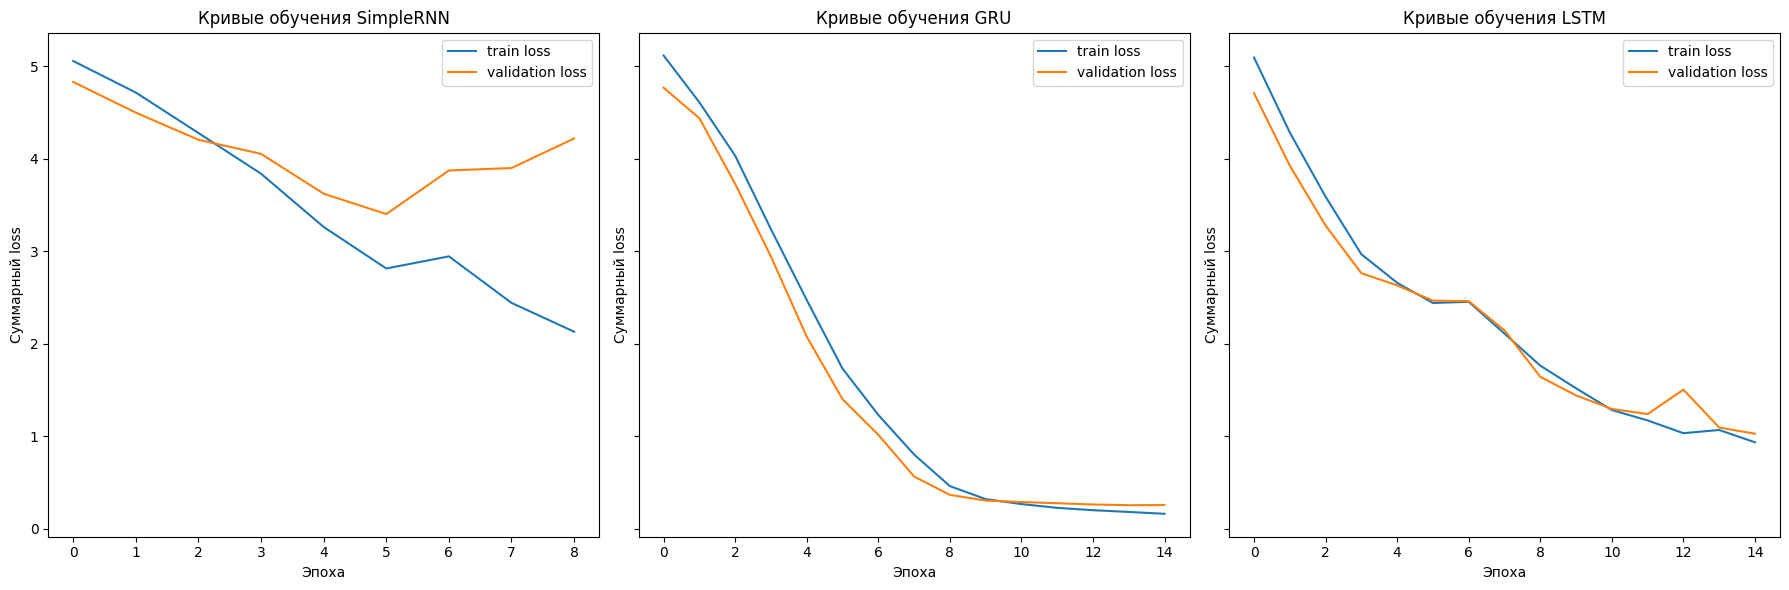

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, (rnn_type, history) in zip(axes, histories.items()):
  ax.plot(history["loss"], label="train loss")
  ax.plot(history["val_loss"], label="validation loss")
  ax.set_title(f"Кривые обучения {rnn_type}")
  ax.set_xlabel("Эпоха")
  ax.set_ylabel("Суммарный loss")
  ax.legend()

plt.tight_layout()
plt.show()

MAE по sentimentв разрезе эпох + итоговое сравнение по mean_binary_f1


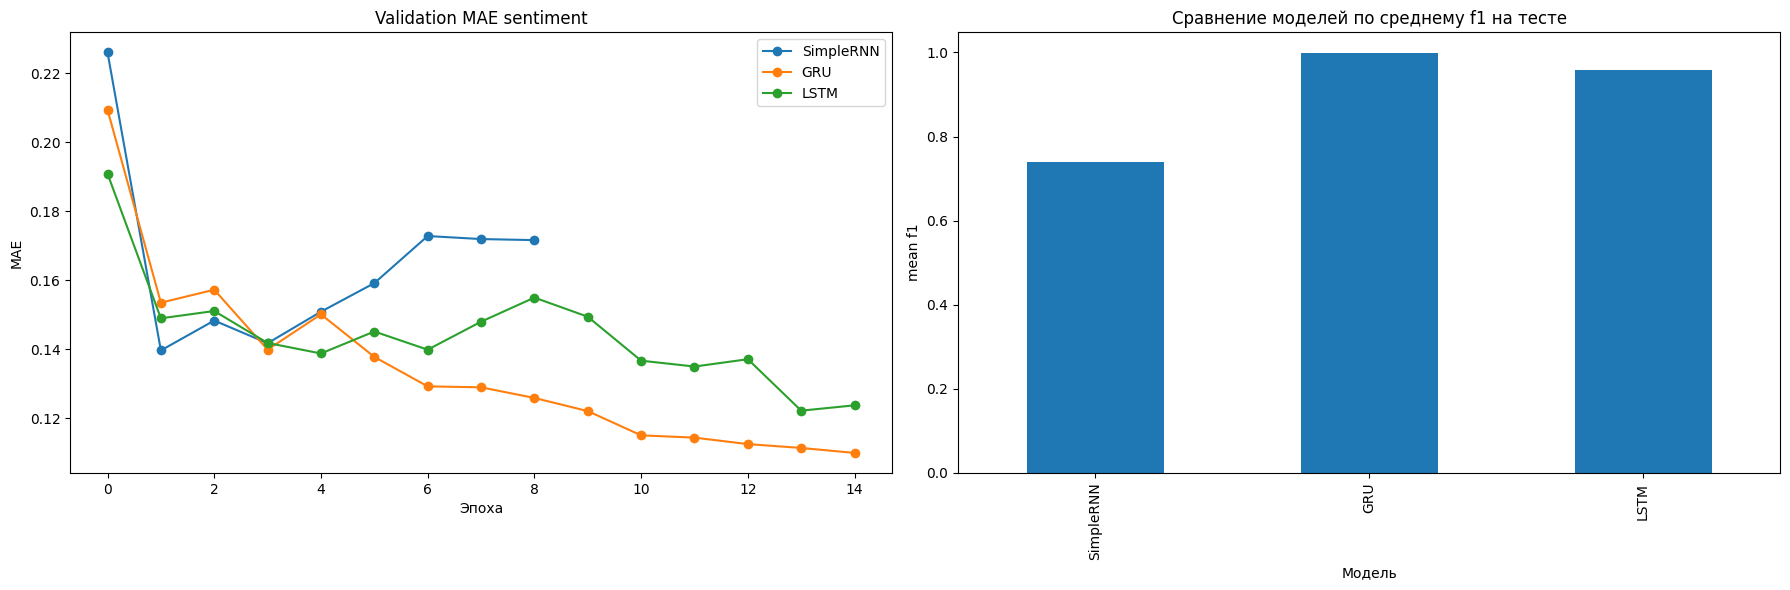

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for rnn_type, hist in histories.items():
    key = "val_sentiment_mae" if "val_sentiment_mae" in hist else "val_sentiment_loss"
    axes[0].plot(hist[key], marker="o", label=rnn_type)

axes[0].set_title("Validation MAE sentiment")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("MAE")
axes[0].legend()

results_df["mean_binary_f1"].plot(kind="bar", ax=axes[1])
axes[1].set_title("Сравнение моделей по среднему f1 на тесте")
axes[1].set_xlabel("Модель")
axes[1].set_ylabel("mean f1")

plt.tight_layout()
plt.show()

Выводы
- SimpleRNN в этом запуске показала худший результат. Средний F1 заметно ниже, чем у GRU и LSTM, а по некоторым флагам модель почти не выделяет положительный класс. обычной RNN сложнее удерживать контекст по всему отзыву такой длины, поэтому она такая слабая

- LSTM оказался посередине, его loss снижался заметно медленнее, чем у GRU, и за 15 эпох модель не успела сойтись, у нее провалены флаг комфорта и тональность

- Помним что у нас идет сравнение с эвристической разметкой, которая достаточно условная

## 12. Выбор лучшей модели

Выбираем лучшую модель по комбинации метрик `mean_binary_f1` и `sentiment_mae`

In [52]:
best_name = results_df.sort_values(["mean_binary_f1", "sentiment_mae"], ascending=[False, True]).index[0]

print(f"Лучшая модель: {best_name}")
print(results_df.loc[best_name])

Лучшая модель: GRU
sentiment_mae     11.3279
sentiment_rmse    20.5442
relevance_f1       0.9979
fit_f1             0.9991
size_f1            1.0000
comfort_f1         0.9920
material_f1        0.9993
quality_f1         0.9950
type_f1            0.9998
color_f1           0.9996
mean_binary_f1     0.9978
Name: GRU, dtype: float64


сохраняем

In [53]:
best_model = keras.models.load_model(model_paths[best_name])
best_model.save("artifacts/models/best_text_model.keras")

## 13. Предсказания для всего датасета

Применяем лучшую модель ко всем отзывам из датасета, чтобы передать дс на 2 этап

Новые столбцы:
- `pred_relevance` - вероятность релевантности (0-1)
- `pred_sentiment_score` - тональность (0–100)
- `pred_has_*_info` - вероятности наличия информации о посадке/размере/комфорте/
  материале/качестве/цвете/типе (0-1)

In [54]:
X_full = texts_to_padded(df["clean_text"])

full_preds = best_model.predict(X_full, batch_size=256, verbose=1)
full_preds = {name: p.ravel() for name, p in zip(output_names, full_preds)}

df["pred_relevance"] = full_preds["relevance"]
df["pred_sentiment_score"] = full_preds["sentiment"] * 100

for k in keywords:
  df[f"pred_has_{k}_info"] = full_preds[k]

89/89 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step


## 14. Сохранение обогащенного дс

In [56]:
df.to_csv("artifacts/predictions/clothing_reviews_enriched_full.csv", index=False)

In [58]:
df_to_save = df.drop(columns=["relevance", "sentiment_score"] + [f"has_{k}_info" for k in keywords])
df_to_save.columns

Index(['Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name', 'full_text', 'clean_text',
       'pred_relevance', 'pred_sentiment_score', 'pred_has_fit_info',
       'pred_has_size_info', 'pred_has_comfort_info', 'pred_has_material_info',
       'pred_has_quality_info', 'pred_has_color_info', 'pred_has_type_info'],
      dtype='object')

In [59]:
df_to_save.to_csv("data/clothing_reviews_enriched.csv", index=False)